# End-to-end Pipeline Testing

Using the demo document linked at https://www.apple.com/hk/en/newsroom/2025/11/apple-intelligence-expands-to-new-languages-including-traditional-chinese

## Imports

In [4]:
from config.settings import RAGConfig
from RAGPipeline import RAGSystem

/usr/local/lib/python3.12/dist-packages/cupy/_environment.py:596: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy-cuda11x, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''
/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for th

## Initialization and Setup

With dense retrieval mode

In [5]:
config = RAGConfig(collection_name="demo_endtoend")
rag_system = RAGSystem(config)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Image store initialized at: ./image_store


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for cls_token: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict

Multi-modal embedding model (DINOv2+Talk2DINO) loaded.
Multi-vector database loaded.


## Ingest Documents

In [6]:
rag_system.ingest_documents("./documents/")

Stored image Apple Intelligence features are now available in traditional Chinese - Apple (HK).pdf_1_383e5799461b54c50d4bbb50ebcba87c (114277 bytes)
Stored image Apple Intelligence features are now available in traditional Chinese - Apple (HK).pdf_2_42661859ad43581847ad44b31a9ea612 (54536 bytes)
Stored image Apple Intelligence features are now available in traditional Chinese - Apple (HK).pdf_3_eec420917435a771dfc28a470d7991d6 (103251 bytes)
Stored image Apple Intelligence features are now available in traditional Chinese - Apple (HK).pdf_4_22c972b8ddda1bcbc350df320c7a6fd6 (143972 bytes)
Stored image Apple Intelligence features are now available in traditional Chinese - Apple (HK).pdf_5_c3f4180672ba246eb7291eddacb51a0f (145876 bytes)
Stored image Apple Intelligence features are now available in traditional Chinese - Apple (HK).pdf_6_2834c5061474f054fad4fe81f526dc41 (53154 bytes)
Stored image Apple Intelligence features are now available in traditional Chinese - Apple (HK).pdf_7_e97acd3

## Query and Generation

In [7]:
question = "What is Genmoji like and how can I use it? Can you give me an example?"

query_results = rag_system.query(question=question, use_enhancement=True, use_vlm=True)

Retrieved 5 images via multi-modal search
Using 5 images as context


Generated Answer

In [8]:
print(query_results["answer"])

Genmoji is a fun feature that allows users to create personalized emojis for their conversations. You can design your own unique emoji by typing in a description or mixing and matching existing emojis. This feature adds a playful touch to your messaging, making it more engaging with family and friends.

For example, you can create a "Rainbow cactus" emoji by describing it, and then you can further customize it by adjusting colors or combining it with other elements. You can also use photos from your library to inspire your designs, allowing for even more creative possibilities.

Overall, Genmoji is all about enhancing communication through visually appealing and personalized emojis that reflect your style and the context of your conversations.


Retrieved Documents

In [9]:
for i in range(len(query_results["source_documents"])):
    print(f"Retrieved document {i+1}: {query_results["source_documents"][i]}")

Retrieved document 1: or combine emoji and text to create something entirely new. With images from
their photo library, users can take Genmoji even further by creating one that is
inspired by a friend or family member. And similar to Image Playground, users can
also change expressions or modify personal attributes to match their contactʼs

latest look.
[IMAGE: Image: A smartphone screen displays a colorful, glowing emoji of a cactus labeled "Rainbow cactus," alongside suggestion icons for creating personalized emojis. This showcases the Genmoji feature, enabling users to add playful and unique elements to their conversations.]
Users can create their own unique emoji with Genmoji, making conversations with family and friends 
more fun and playful.
Take Notes to the Next Level with Image Wand
With Image Wand in the tool palette, users can quickly create images in the
Notes app using the written or visual context already captured within a note.
Retrieved document 2: Clean Up helps users

Retrieved Images

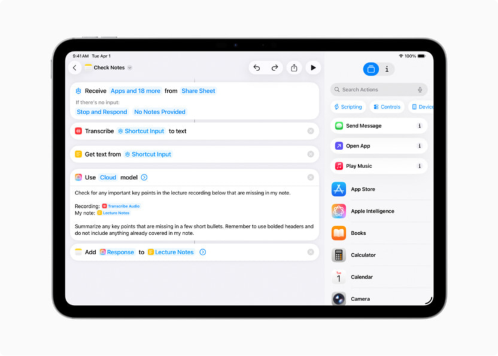

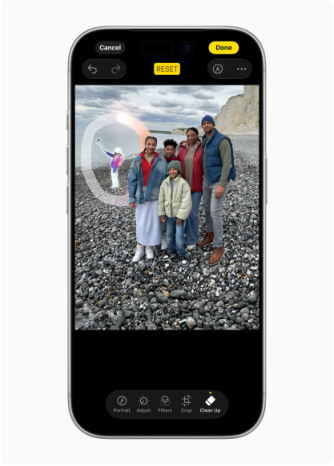

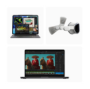

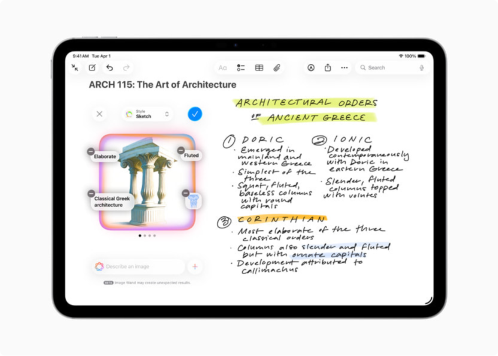

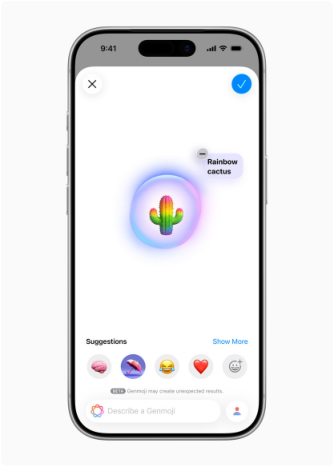

In [10]:
from utils.image_extraction import data_url_to_pil

for image_url in query_results["context_images"]:
    image = data_url_to_pil(image_url)
    display(image)

## Generation Without Multi-modal Retrieval

In [13]:
query_results_nomultimodal = rag_system.query(question=question, use_enhancement=True, use_vlm=False)

print(query_results_nomultimodal["answer"])

Retrieved 5 images via multi-modal search
Using 5 images as context
Genmoji is a fun and creative feature that allows you to create your own unique emojis. You can make conversations with family and friends more playful by using Genmoji to craft emojis that reflect your personal style or express your feelings. 

To use Genmoji, you can type a description of what you want the emoji to look like, mix together multiple existing emojis, or even combine emoji and text to create something entirely new. Additionally, you can use images from your photo library to inspire your creations, such as designing an emoji that resembles a friend or family member.

For example, if you wanted to create an emoji inspired by your friend who loves cats, you might start by mixing a cat emoji with a party hat emoji to reflect their fun personality. You could describe it in your own words, like "A cat with a colorful party hat," and Genmoji would help you bring that idea to life!


## Generation Without Retrieval

In [15]:
from models.llm_openai_azure import LLM_OpenAI_Azure

llm_client = LLM_OpenAI_Azure(config)

In [16]:
response = llm_client.generate_response(question)

print(response["answer"])

Genmoji is a creative tool that allows users to generate personalized emojis and stickers based on their preferences or input. It's often used for fun and self-expression, enabling users to create custom emoji that represent their personality or emotions in a more tailored way than standard emojis.

### How to Use Genmoji:

1. **Access the Platform**: Visit the Genmoji website or app where the service is available.
   
2. **Select Options**: You may have options to choose various features such as facial expressions, accessories, hairstyles, and backgrounds.

3. **Customize Your Emoji**: Use the provided tools to customize your emoji to your liking. You can usually adjust colors, add features, or apply different styles.

4. **Save or Share**: After creating your emoji, you can save it to your device or share it on social media platforms.

### Example:

Let's say you're feeling happy and want an emoji that reflects that:

1. **Choose a Base Expression**: Start with a smiling face.
2. **A